In [3]:
from pathlib import Path
# Chemin du dossier data/
data_folder = Path('extracted_files/data')

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# files to upload
target_universities = {
    'Caltech': 'Caltech36.gml',
    'MIT': 'MIT8.gml',
    'Johns Hopkins': 'Johns Hopkins55.gml'
}

graphs = {}

# reading and constructing the graphs
for name, filename in target_universities.items():
    path = data_folder / filename
    G = nx.read_gml(path, label='id')
    # take the largest connected component
    G_lcc = max(nx.connected_components(G), key=len)
    G = G.subgraph(G_lcc).copy()
    graphs[name] = G


2 - Social Network Analysis with the Facebook100 Dataset

(a) Degree distribution

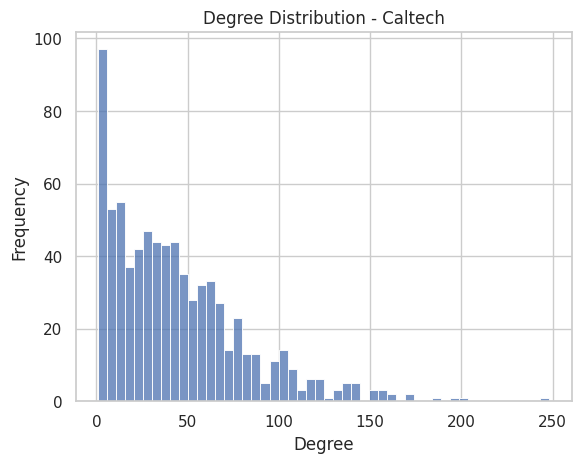

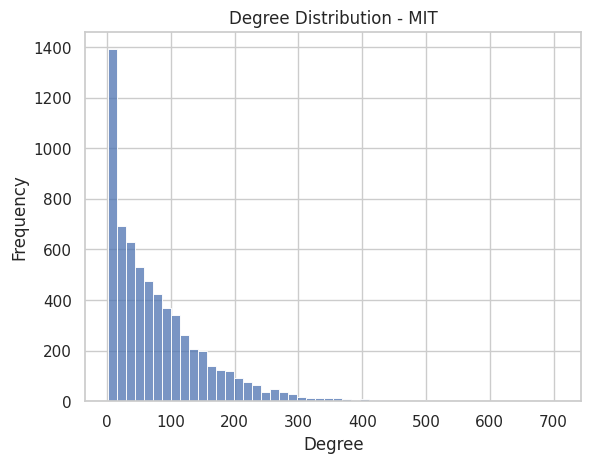

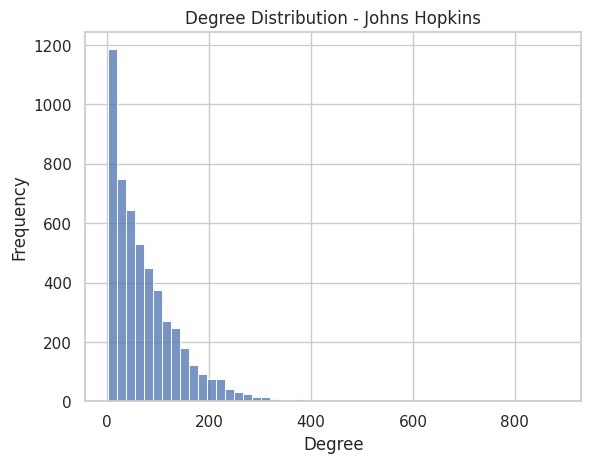

In [5]:
for name, G in graphs.items():
    degrees = [d for n, d in G.degree()]
    plt.figure()
    sns.histplot(degrees, bins=50, kde=False)
    plt.title(f'Degree Distribution - {name}')
    plt.xlabel('Degree')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()


(b) Clustering and density

In [6]:
for name, G in graphs.items():
    global_clustering = nx.transitivity(G)
    avg_local_clustering = nx.average_clustering(G)
    edge_density = nx.density(G)

    print(f"{name}")
    print(f"  - Global clustering coefficient: {global_clustering:.4f}")
    print(f"  - Mean local clustering coefficient: {avg_local_clustering:.4f}")
    print(f"  - Edge density: {edge_density:.6f}")
    print()


Caltech
  - Global clustering coefficient: 0.2913
  - Mean local clustering coefficient: 0.4091
  - Edge density: 0.057429

MIT
  - Global clustering coefficient: 0.1803
  - Mean local clustering coefficient: 0.2724
  - Edge density: 0.012261

Johns Hopkins
  - Global clustering coefficient: 0.1932
  - Mean local clustering coefficient: 0.2690
  - Edge density: 0.014034



(c) Scatter : degree vs local clustering

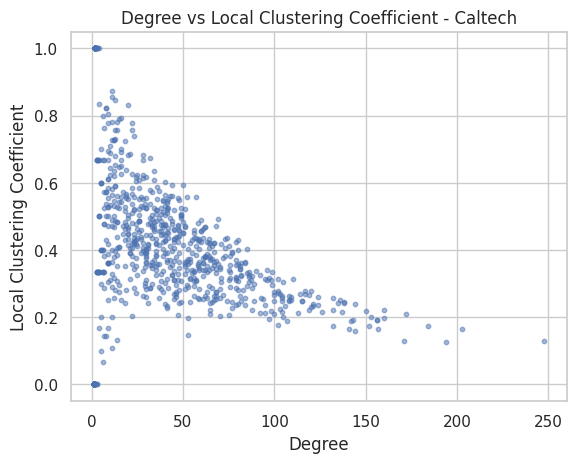

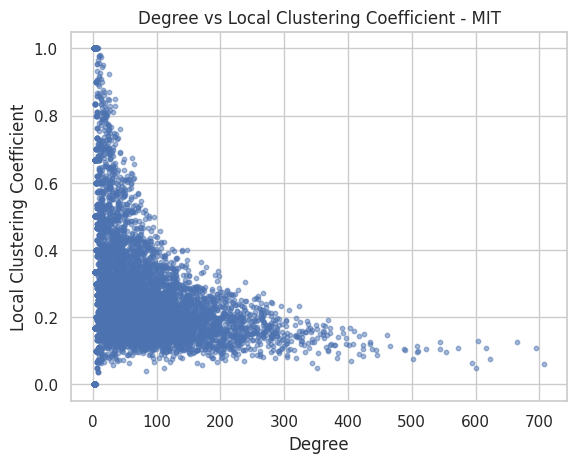

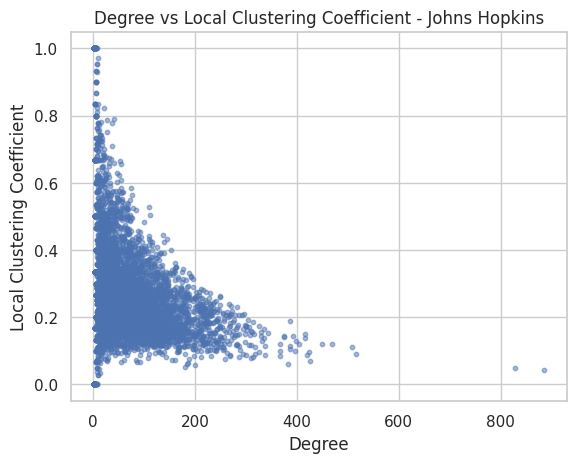

In [7]:
for name, G in graphs.items():
    degrees = dict(G.degree())
    clustering = nx.clustering(G)
    degree_values = []
    clustering_values = []

    for node in G.nodes():
        degree_values.append(degrees[node])
        clustering_values.append(clustering[node])

    plt.figure()
    plt.scatter(degree_values, clustering_values, alpha=0.5, s=10)
    plt.title(f'Degree vs Local Clustering Coefficient - {name}')
    plt.xlabel('Degree')
    plt.ylabel('Local Clustering Coefficient')
    plt.grid(True)
    plt.show()


We often observe an inverse trend: the higher the degree, the lower the local clustering.

This can indicate the presence of hubs connected to nodes that are poorly connected to each other.

3 Assortativity Analysis

In [8]:
# files to upload
universities = {
    'MIT': 'MIT8.gml',
    'Johns Hopkins': 'Johns Hopkins55.gml',
    'Stanford': 'Stanford3.gml',
    'Berkeley': 'Berkeley13.gml',
    'Harvard': 'Harvard1.gml',
    'Princeton': 'Princeton12.gml',
    'Yale': 'Yale4.gml',
    'Columbia': 'Columbia2.gml',
    'Cornell': 'Cornell5.gml',
    'Caltech': 'Caltech36.gml',
    'UCLA': 'UCLA26.gml',
    'Uni Chicago': 'UChicago30.gml',
    'Uni Pennesylvania': 'UPenn7.gml',
    'Virginia': 'Virginia63.gml',
    'Vermont': 'Vermont70.gml',
    'NYU': 'NYU9.gml',
    'Nothwestern': 'Northwestern25.gml',
    'Northeastern': 'Northeastern19.gml',
    'Duke': 'Duke14.gml',
    'Hamilton': 'Hamilton46.gml',
    'Howard': 'Howard90.gml',
    'Indiana': 'Indiana69.gml',
    'Mississippi': 'Mississippi66.gml',
    'Brown': 'Brown11.gml',
    'American': 'American75.gml',
    'Darthmouth': 'Dartmouth6.gml',
    'Emory': 'Emory27.gml',
    'Georgetown': 'Georgetown15.gml',
    'Haverford': 'Haverford76.gml',
    'Maryland': 'Maryland58.gml',
    'Michigan': 'Michigan23.gml',
    'Rice':     'Rice31.gml',
    'Rochester': 'Rochester38.gml',
    'Rutgers': 'Rutgers89.gml',
    'Santa': 'Santa74.gml',
    'Simmons': 'Simmons81.gml',
    'Swarthmore': 'Swarthmore42.gml',
    'Texas': 'Texas80.gml',
}

In [9]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

q3_graphs = []

# reading and constructing the graphs
for name, filename in universities.items():
    path = data_folder / filename
    G = nx.read_gml(path, label='id')
    G = nx.Graph(G)  
    q3_graphs.append((name, G))

In [10]:
# vertex attributes
attributes = ['student_fac', 'major_index', 'dorm', 'gender', 'degree']

#results
results=[]

for name, G in q3_graphs:
    for attr in attributes:
        n = G.number_of_nodes()
        if attr == 'degree':
                assort = nx.degree_assortativity_coefficient(G)
        else :
            assort_major = nx.attribute_assortativity_coefficient(G, attr)
        results.append({
            'university': name,
            'attribute': attr,
            'assortativity': assort_major,
            'n_nodes': G.number_of_nodes(),
        })


In [11]:
import pandas as pd
df_results = pd.DataFrame(results)

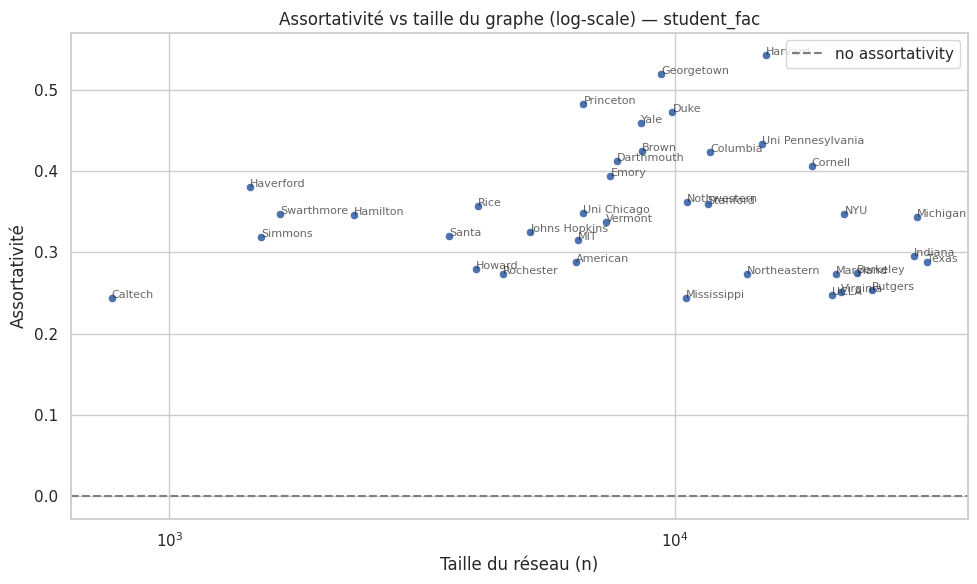

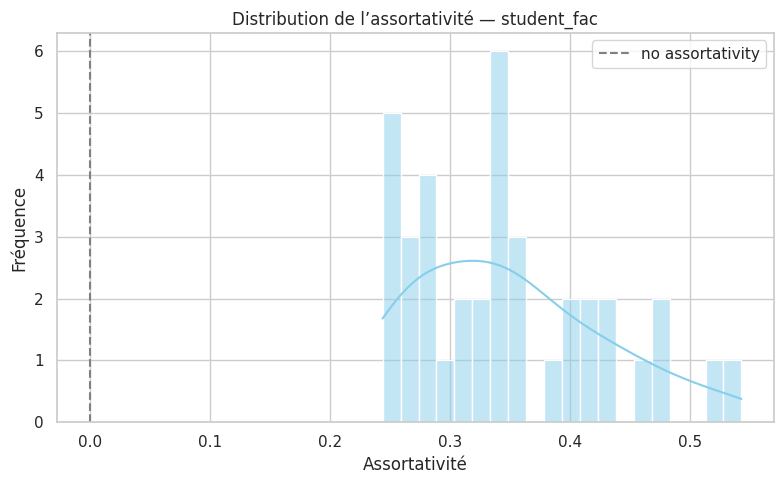

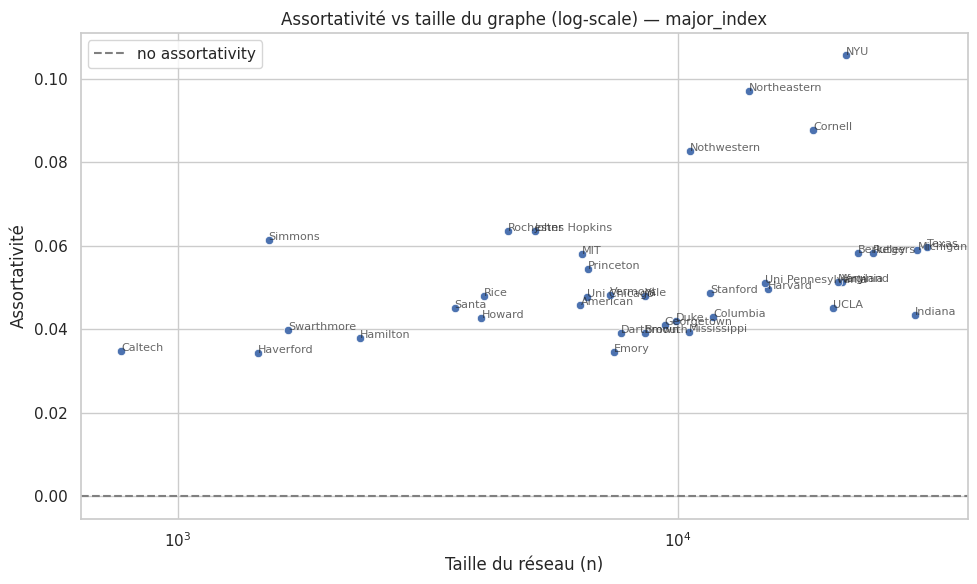

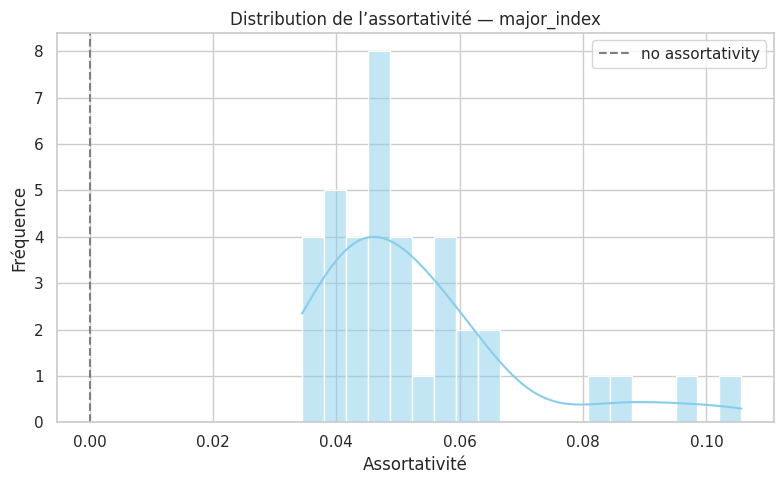

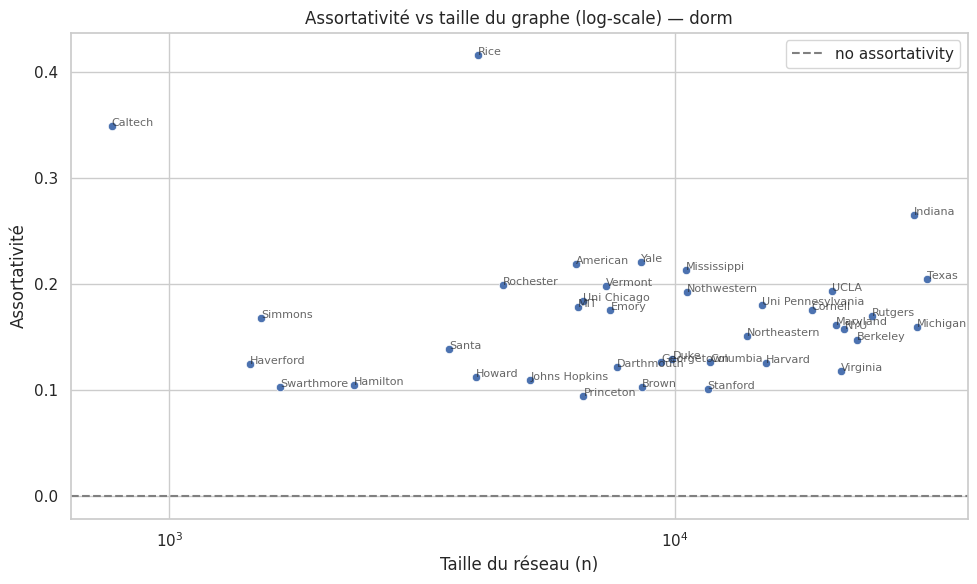

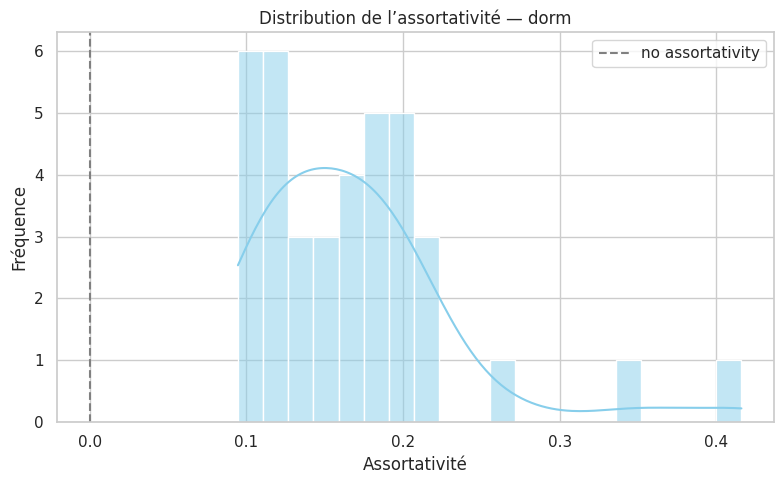

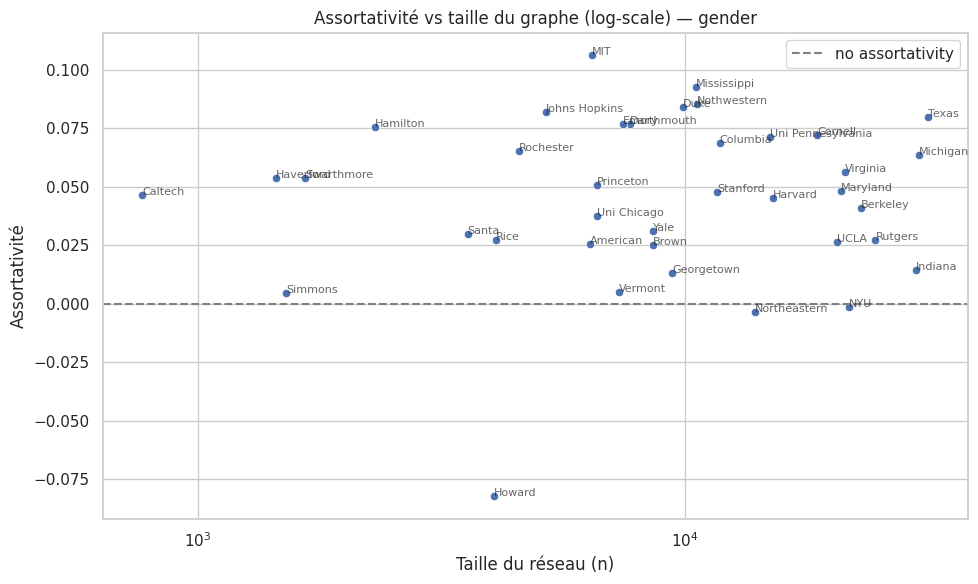

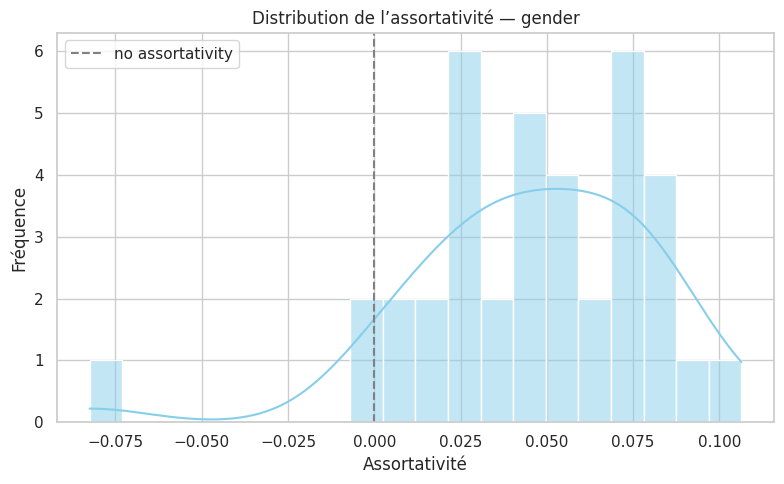

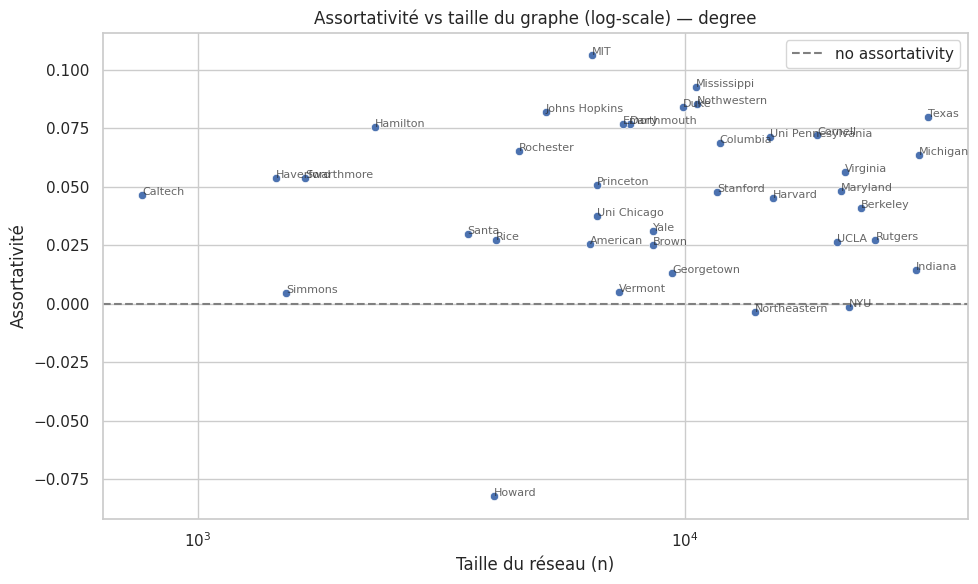

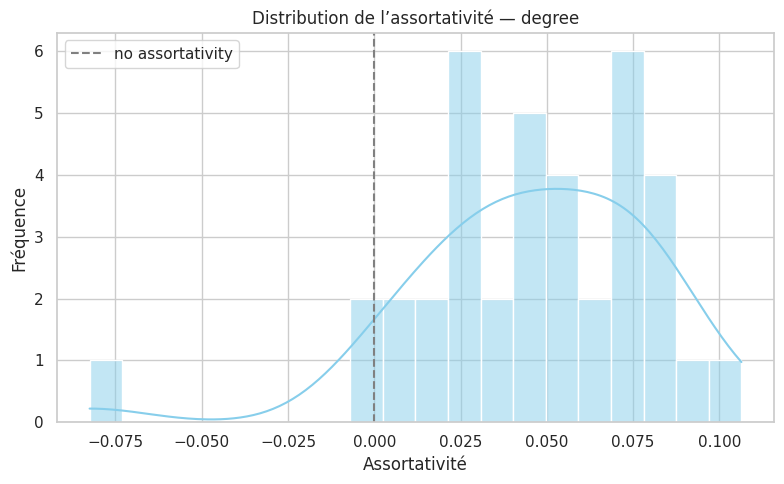

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

for attr in attributes:
    subset = df_results[df_results['attribute'] == attr]

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=subset, x='n_nodes', y='assortativity')

    # Add labels for each point
    for _, row in subset.iterrows():
        plt.text(row['n_nodes'], row['assortativity'], row['university'],
                 fontsize=8, alpha=0.7)
    # Scattre
    plt.axhline(0, color='gray', linestyle='--', label='no assortativity')
    plt.xscale('log')
    plt.title(f"Assortativité vs taille du graphe (log-scale) — {attr}")
    plt.xlabel("Taille du réseau (n)")
    plt.ylabel("Assortativité")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Histogramme
    plt.figure(figsize=(8, 5))
    sns.histplot(subset['assortativity'], kde=True, bins=20, color='skyblue')
    plt.axvline(0, color='gray', linestyle='--', label='no assortativity')
    plt.title(f"Distribution de l’assortativité — {attr}")
    plt.xlabel("Assortativité")
    plt.ylabel("Fréquence")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



In general, it is observed that as the size of networks increases, assortativity tends to grow, although this trend is not always verified for all attributes.

The attributes student_fac, major, and dorm exhibit positive assortativity, indicating that users are more likely to connect with others who share these same characteristics. This reflects strong homophily: friendships on Facebook often form between students from the same dorm, major, or status (student or faculty member). The student_fac attribute shows particularly high assortativity, exceeding that of other attributes by 0.2, suggesting a clear separation between students and professors in friendship ties. Major has an assortativity around 0.1, while dorm can reach approximately 0.35, highlighting the importance of residence in forming connections.

On the other hand, the attributes degree (number of connections) and gender (sex) show assortativity close to zero or negative in some universities. For example, Howard exhibits negative assortativity for these two attributes, while NYU, Indiana, and Vermont are close to neutrality. This means that the most popular individuals (with a high degree) do not necessarily connect with each other but rather with less-connected individuals. Similarly, connections between genders do not show a marked preference, which may reflect mixed and balanced interactions between men and women, often influenced by social or romantic dynamics.

4 Link Prediction

Évaluation sur Caltech (6440 nœuds, 251252 arêtes)
  Calcul CommonNeighbors...
  Calcul Jaccard...
  Calcul AdamicAdar...
Évaluation sur MIT (5180 nœuds, 186586 arêtes)
  Calcul CommonNeighbors...
  Calcul Jaccard...
  Calcul AdamicAdar...


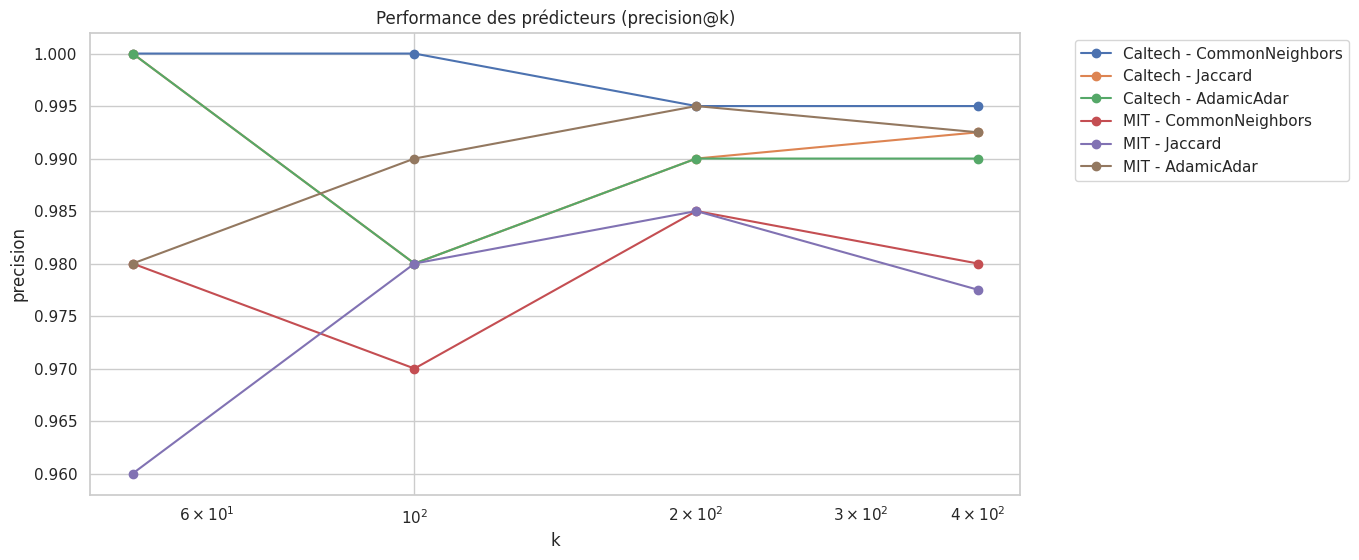

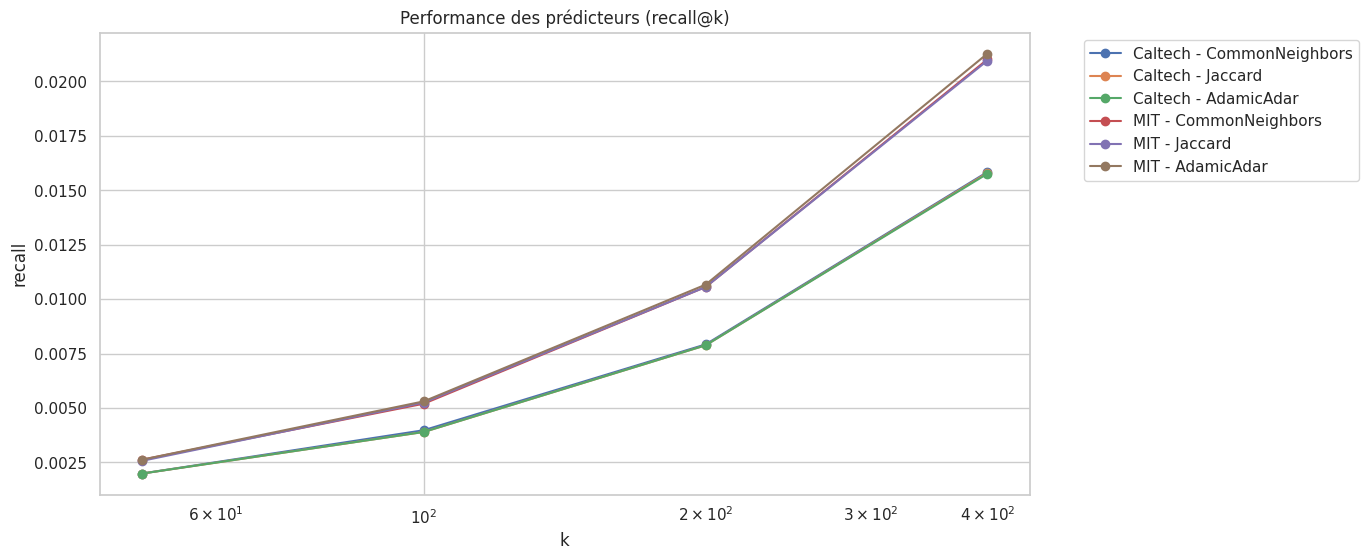

In [13]:
import networkx as nx
import random
import math
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt
from tqdm import tqdm

# Classe abstraite pour la prédiction de liens
class LinkPredictor(ABC):
    def __init__(self, graph):
        self.graph = graph
        
    @abstractmethod
    def predict(self, node_pairs):
        pass

# personalized PageRank
class CommonNeighborsPredictor(LinkPredictor):
    def predict(self, node_pairs):
        scores = []
        for u, v in node_pairs:
            common = len(set(self.graph.neighbors(u)) & set(self.graph.neighbors(v)))
            scores.append((u, v, common))
        return scores

class JaccardPredictor(LinkPredictor):
    def predict(self, node_pairs):
        scores = []
        for u, v in node_pairs:
            neighbors_u = set(self.graph.neighbors(u))
            neighbors_v = set(self.graph.neighbors(v))
            intersection = len(neighbors_u & neighbors_v)
            union = len(neighbors_u | neighbors_v)
            score = intersection / union if union else 0
            scores.append((u, v, score))
        return scores

class AdamicAdarPredictor(LinkPredictor):
    def predict(self, node_pairs):
        scores = []
        degree_cache = {}
        for u, v in node_pairs:
            common_neighbors = set(self.graph.neighbors(u)) & set(self.graph.neighbors(v))
            score = 0
            for z in common_neighbors:
                if z not in degree_cache:
                    degree_cache[z] = len(list(self.graph.neighbors(z)))
                degree = degree_cache[z]
                if degree > 1:
                    score += 1 / math.log(degree)
            scores.append((u, v, score))
        return scores

# evaluation function
def evaluate_predictor(G, predictor_class, f=0.1, k_values=[50, 100, 200, 400], max_samples=100000):
    # creating a copy of the graph
    G_train = G.copy()
    
    # Separating edges for training and testing
    edges = list(G.edges())
    random.shuffle(edges)
    n_remove = int(len(edges) * f)
    removed_edges = set(edges[:n_remove])
    G_train.remove_edges_from(removed_edges)
    
    # Sample non-edges
    non_edges = list(nx.non_edges(G_train))
    random.shuffle(non_edges)
    samples = non_edges[:max_samples] + list(removed_edges)
    
    # Calculate scores
    predictor = predictor_class(G_train)
    scores = predictor.predict(samples)
    
    # Sorted scores
    sorted_scores = sorted(scores, key=lambda x: x[2], reverse=True)
    
    # Metrics calculation
    results = {}
    removed_set = {(u, v) for u, v in removed_edges} | {(v, u) for u, v in removed_edges}
    
    for k in k_values:
        top_k = {(u, v) for u, v, _ in sorted_scores[:k]}
        true_positives = len(top_k & removed_set)
        
        precision = true_positives / k if k > 0 else 0
        recall = true_positives / len(removed_edges) if removed_edges else 0
        
        results[k] = {'precision': precision, 'recall': recall}
    
    return results

# Example usage
selected_graphs = [('Caltech', q3_graphs[0][1]), ('MIT', q3_graphs[1][1])]
metrics = {
    'CommonNeighbors': CommonNeighborsPredictor,
    'Jaccard': JaccardPredictor,
    'AdamicAdar': AdamicAdarPredictor
}

results = {}

for name, G in selected_graphs:
    print(f"Évaluation sur {name} ({G.number_of_nodes()} nœuds, {G.number_of_edges()} arêtes)")
    graph_results = {}
    
    for metric_name, predictor_class in metrics.items():
        print(f"  Calcul {metric_name}...")
        metric_results = evaluate_predictor(G, predictor_class)
        graph_results[metric_name] = metric_results
    
    results[name] = graph_results

# Visualisation des résultats
def plot_metrics(results, metric_type='precision'):
    plt.figure(figsize=(12, 6))
    
    for graph_name, graph_data in results.items():
        for metric_name, metric_data in graph_data.items():
            x = list(metric_data.keys())
            y = [v[metric_type] for v in metric_data.values()]
            plt.plot(x, y, marker='o', label=f"{graph_name} - {metric_name}")
    
    plt.title(f'Performance des prédicteurs ({metric_type}@k)')
    plt.xlabel('k')
    plt.ylabel(metric_type)
    plt.xscale('log')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.show()

plot_metrics(results, 'precision')
plot_metrics(results, 'recall')

5 Label Propagation

In [14]:
import numpy as np
import networkx as nx

def label_propagation(G, labels, max_iter=500):
    A = nx.to_numpy_array(G)
    n = A.shape[0]

    # Associateation of nodes to indices
    node_list = list(G.nodes())
    node_to_idx = {node: idx for idx, node in enumerate(node_list)}

    # Transition matrix
    D = np.diag(A.sum(axis=1))
    P = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if A[i, j] > 0:
                P[i, j] = A[i, j] / D[i, i]

    # Labels encodage
    unique_labels = list(set(labels.values()))
    label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
    Y = np.zeros((n, len(unique_labels)))

    for node_id, label in labels.items():
        if node_id in node_to_idx:
            idx = node_to_idx[node_id]
            Y[idx, label_to_index[label]] = 1

    # Propagation with limited iterations
    for _ in range(max_iter):
        Y_new = np.dot(P, Y)
        if np.array_equal(np.argmax(Y, axis=1), np.argmax(Y_new, axis=1)):
            break
        Y = Y_new

    # Inverse conversion of labels
    index_to_label = {v: k for k, v in label_to_index.items()}
    predicted_indices = np.argmax(Y, axis=1)
    predicted_labels = [index_to_label[i] for i in predicted_indices]

    # Returning the labels in the original node format
    return {node: predicted_labels[node_to_idx[node]] for node in G.nodes()}


In [15]:
# Here we will use the graph of Duke University
nx_graph = nx.read_gml(data_folder / universities['Duke'], label='id')
nx_graph = nx.Graph(nx_graph)  # Convertir en graphe non orienté

# We create graphs by removing a percentage of nodes (10%, 20%, 30%)
def remove_nodes(G, percentage):
    num_nodes_to_remove = int(len(G.nodes()) * percentage)
    nodes_to_remove = np.random.choice(G.nodes(), num_nodes_to_remove, replace=False)
    G.remove_nodes_from(nodes_to_remove)
    return G
nx_graph_10 = remove_nodes(nx_graph.copy(), 0.1)
nx_graph_20 = remove_nodes(nx_graph.copy(), 0.2)
nx_graph_30 = remove_nodes(nx_graph.copy(), 0.3)

LPA_10_dorm = label_propagation(nx_graph_10, nx.get_node_attributes(nx_graph_10, 'dorm'))
LPA_20_dorm = label_propagation(nx_graph_20, nx.get_node_attributes(nx_graph_20, 'dorm'))
LPA_30_dorm = label_propagation(nx_graph_30, nx.get_node_attributes(nx_graph_30, 'dorm'))
LPA_10_major = label_propagation(nx_graph_10, nx.get_node_attributes(nx_graph_10, 'major_index'))
LPA_20_major = label_propagation(nx_graph_20, nx.get_node_attributes(nx_graph_20, 'major_index'))
LPA_30_major = label_propagation(nx_graph_30, nx.get_node_attributes(nx_graph_30, 'major_index'))
LPA_10_gender = label_propagation(nx_graph_10, nx.get_node_attributes(nx_graph_10, 'gender'))
LPA_20_gender = label_propagation(nx_graph_20, nx.get_node_attributes(nx_graph_20, 'gender'))
LPA_30_gender = label_propagation(nx_graph_30, nx.get_node_attributes(nx_graph_30, 'gender'))


In [16]:
def accuracy_score(y_true, y_pred):
    correct = sum(1 for true, pred in zip(y_true, y_pred) if true == pred)
    return correct / len(y_true)

# We create a dictionary to store the results
results = {
    '10%': {
        'dorm': accuracy_score(list(nx.get_node_attributes(nx_graph_10, 'dorm').values()), list(LPA_10_dorm.values())),
        'major': accuracy_score(list(nx.get_node_attributes(nx_graph_10, 'major_index').values()), list(LPA_10_major.values())),
        'gender' : accuracy_score(list(nx.get_node_attributes(nx_graph_10, 'gender').values()), list(LPA_10_gender.values())),
    },
    '20%': {
        'dorm': accuracy_score(list(nx.get_node_attributes(nx_graph_20, 'dorm').values()), list(LPA_20_dorm.values())),
        'major': accuracy_score(list(nx.get_node_attributes(nx_graph_20, 'major_index').values()), list(LPA_20_major.values())),
        'gender' : accuracy_score(list(nx.get_node_attributes(nx_graph_20, 'gender').values()), list(LPA_20_gender.values())),
    },
    '30%': {
        'dorm': accuracy_score(list(nx.get_node_attributes(nx_graph_30, 'dorm').values()), list(LPA_30_dorm.values())),
        'major': accuracy_score(list(nx.get_node_attributes(nx_graph_30, 'major_index').values()), list(LPA_30_major.values())),
        'gender' : accuracy_score(list(nx.get_node_attributes(nx_graph_30, 'gender').values()), list(LPA_30_gender.values())),
        
    }
}

# Show results
import pandas as pd
df_results = pd.DataFrame(results).T
df_results.columns = ['Dorm', 'Major', 'Gender']
df_results.reset_index(inplace=True)
df_results.rename(columns={'index': 'Percentage'}, inplace=True)
df_results.to_csv('results.csv', index=False)
df_results.head()


,Percentage,Dorm,Major,Gender
0,10%,0.292050,0.197844,0.443746
1,20%,0.290172,0.201238,0.442648
2,30%,0.290458,0.196766,0.449257


6 Community Detection

In [17]:
import networkx as nx
from networkx.algorithms.community import label_propagation_communities
from collections import defaultdict
import matplotlib.pyplot as plt

def detect_communities(G):
    # Utilize the label propagation algorithm to detect communities
    comms = list(label_propagation_communities(G))
    # Return the dict {node: community_id}
    node2comm = {}
    for i, comm in enumerate(comms):
        for node in comm:
            node2comm[node] = i
    return node2comm

def compute_homogeneity(G, node2comm, attr):
    # Measure the propagation of pairs within the same community that share the same attribute
    attr_dict = nx.get_node_attributes(G, attr)
    comm2nodes = defaultdict(list)
    for node, cid in node2comm.items():
        comm2nodes[cid].append(node)
    same_attr, total = 0, 0
    for nodes in comm2nodes.values():
        for i in range(len(nodes)):
            for j in range(i+1, len(nodes)):
                n1, n2 = nodes[i], nodes[j]
                if attr_dict.get(n1) is not None and attr_dict.get(n2) is not None:
                    total += 1
                    if attr_dict[n1] == attr_dict[n2]:
                        same_attr += 1
    return same_attr / total if total > 0 else 0

(a) Hypothesis: Students sharing the same dormitory ("dorm") are more likely to belong to the same structurally detected community in the friendship graph.

In [20]:
# Calculate the homogeneity of the communities detected by the label propagation algorithm
indices = [30 , 31 , 32 , 33 , 34] # 5 consecutifs graphs 
results = []

for idx in indices :
    name , G = q3_graphs [ idx ]
    node2comm = detect_communities ( G )
    score = compute_homogeneity (G , node2comm , 'dorm')
    print ( f"Homogeneity for {name} : {score:.4f}" )
    results . append (( name , score ) )

mean_score = sum ( score for _ , score in results ) / len ( results )
print ( f"Mean homogeneity : {mean_score:.4f}" )

Homogeneity for Michigan : 0.2511
Homogeneity for Rice : 0.1586
Homogeneity for Rochester : 0.1869
Homogeneity for Rutgers : 0.3566
Homogeneity for Santa : 0.1629
Mean homogeneity : 0.2232


(b) Hypothesis: Students sharing the same major ("major_index") are more likely to belong to the same structurally detected community in the friendship graph.

In [21]:
# Calculate the homogeneity of the communities detected by the label propagation algorithm
indices = [30 , 31 , 32 , 33 , 34] # 5 consecutifs graphs 
results = []

for idx in indices :
    name , G = q3_graphs [ idx ]
    node2comm = detect_communities ( G )
    score = compute_homogeneity (G , node2comm , 'major_index')
    print ( f"Homogeneity for {name} : {score:.4f}" )
    results . append (( name , score ) )

mean_score = sum ( score for _ , score in results ) / len ( results )
print ( f"Mean homogeneity : {mean_score:.4f}" )

Homogeneity for Michigan : 0.0426
Homogeneity for Rice : 0.0489
Homogeneity for Rochester : 0.0531
Homogeneity for Rutgers : 0.0336
Homogeneity for Santa : 0.0615
Mean homogeneity : 0.0479


(c) Hypothesis: Students sharing the same gender ("gender") are more likely to belong to the same structurally detected community in the friendship graph.

In [22]:
# Calculate the homogeneity of the communities detected by the label propagation algorithm
indices = [30 , 31 , 32 , 33 , 34] # 5 consecutifs graphs 
results = []

for idx in indices :
    name , G = q3_graphs [ idx ]
    node2comm = detect_communities ( G )
    score = compute_homogeneity (G , node2comm , 'gender')
    print ( f"Homogeneity for {name} : {score:.4f}" )
    results . append (( name , score ) )

mean_score = sum ( score for _ , score in results ) / len ( results )
print ( f"Mean homogeneity : {mean_score:.4f}" )

Homogeneity for Michigan : 0.4268
Homogeneity for Rice : 0.4425
Homogeneity for Rochester : 0.4392
Homogeneity for Rutgers : 0.4342
Homogeneity for Santa : 0.4546
Mean homogeneity : 0.4394
